In [ ]:
import copy
import time

import pandas as pd
import torch
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples

import bofire.surrogates.api as surrogates
from bofire.benchmarks.api import Hartmann, SpuriousFeaturesWrapper
from bofire.data_models.surrogates.api import (
    EnsembleMapSaasSingleTaskGPSurrogate,
    SingleTaskGPSurrogate,
)
from bofire.strategies import utils
from bofire.strategies.api import RandomStrategy, SoboStrategy
from bofire.strategies.predictives.optimize_mcts import (
    MCTS,
    Groups,
    NChooseK,
    _SelectionTracker,
)
from bofire.utils.torch_tools import tkwargs


benchmark = SpuriousFeaturesWrapper(Hartmann(dim=6), n_spurious_features=6, max_count=6)
random_strategy = RandomStrategy.make(domain=benchmark.domain)

experiments = pd.read_csv("experiments.csv")

strategy = SoboStrategy.make(
    domain=benchmark.domain,
)
# surrogate_specs=BotorchSurrogates(
#     surrogates=[
#         EnsembleMapSaasSingleTaskGPSurrogate(inputs=benchmark.domain.inputs, outputs=benchmark.domain.outputs)
#         ]
#     )
# )

strategy.tell(experiments.loc[:9].copy())
acqf = strategy._get_acqfs(n=1)[0]

bounds = utils.get_torch_bounds_from_domain(
    benchmark.domain, strategy.input_preprocessing_specs
)


def reward_fn(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    if len(selected_features) == 0:
        candidates = torch.zeros((1, bounds.shape[1]), **tkwargs)
        return acqf(candidates.unsqueeze(-2)).max().item()
    local_bounds = bounds[:, selected_features]
    sobol_samples = draw_sobol_samples(bounds=local_bounds, n=64, q=1).squeeze(1)
    candidates = torch.zeros((sobol_samples.shape[0], bounds.shape[1]), **tkwargs)
    candidates[:, selected_features] = sobol_samples
    return acqf(candidates.unsqueeze(-2)).max().item()


def reward_fn2(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    fixed = {
        i: 0.0
        for i in range(len(benchmark.domain.inputs.get_keys()))
        if i not in selected_features
    }
    candidates, acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=1,
        raw_samples=64,
        fixed_features=fixed,
    )
    return acq_value.item()


def reward_fn3(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    fixed = {
        i: 0.0
        for i in range(len(benchmark.domain.inputs.get_keys()))
        if i not in selected_features
    }
    candidates, acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=20,
        raw_samples=2048,
        fixed_features=fixed,
    )
    return acq_value.item()


# candidates = random_strategy.ask(10)
# experiments = benchmark.f(candidates, return_complete=True)

# experiments[["x_3"]].sum()

In [ ]:
experiments.loc[:9]

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.340387,0.939384,0.000000,0.000000,0.988805,0.000000,0.000000,0.000000,0.059174,0.283508,0.651115,0.000000,-0.093813,True
1,0.000000,0.000000,0.215787,0.694921,0.607090,0.000000,0.659854,0.864603,0.000000,0.000000,0.000000,0.683445,-0.004209,True
2,0.162249,0.000000,0.000000,0.000000,0.670102,0.000000,0.000000,0.837538,0.313773,0.000000,0.194253,0.959623,-0.003265,True
3,0.646861,0.151070,0.000000,0.023944,0.000000,0.000000,0.000000,0.000000,0.164506,0.147815,0.000000,0.930434,-0.005103,True
4,0.000000,0.492742,0.190961,0.000000,0.058192,0.165081,0.000000,0.138372,0.000000,0.000000,0.000000,0.281132,-0.040627,True
5,0.971656,0.341037,0.247311,0.117081,0.000000,0.000000,0.101465,0.000000,0.000000,0.612449,0.000000,0.000000,-0.002416,True
6,0.009727,0.318712,0.000000,0.000000,0.562950,0.501431,0.000000,0.000000,0.130447,0.776044,0.000000,0.000000,-0.216006,True
7,0.873356,0.273255,0.000000,0.000000,0.395537,0.000000,0.000000,0.913477,0.422242,0.558164,0.000000,0.000000,-0.007566,True
8,0.000000,0.000000,0.000000,0.921305,0.478782,0.555382,0.843183,0.000000,0.674322,0.000000,0.840498,0.000000,-0.019061,True
9,0.000000,0.861323,0.000000,0.000000,0.246309,0.000000,0.367699,0.574321,0.000000,0.771572,0.253270,0.000000,-0.010974,True


In [ ]:
surrogate_data = EnsembleMapSaasSingleTaskGPSurrogate(
    inputs=benchmark.domain.inputs, outputs=benchmark.domain.outputs
)
surrogate = surrogates.map(surrogate_data)

cv_train, cv_test, _ = surrogate.cross_validate(experiments, folds=5)
display(cv_test.get_metrics())

,MAE,MSD,R2,MAPE,PEARSON,SPEARMAN,FISHER
0,0.055461,0.01794,0.971924,10.792482,0.98692,0.96097,5.674047e-18


In [ ]:
surrogate_data = SingleTaskGPSurrogate(
    inputs=benchmark.domain.inputs, outputs=benchmark.domain.outputs
)
surrogate = surrogates.map(surrogate_data)

cv_train, cv_test, _ = surrogate.cross_validate(experiments, folds=5)
display(cv_test.get_metrics())

,MAE,MSD,R2,MAPE,PEARSON,SPEARMAN,FISHER
0,0.068496,0.026162,0.959058,17.938245,0.981498,0.955696,5.674047e-18


In [ ]:
surrogate_data = EnsembleMapSaasSingleTaskGPSurrogate(
    inputs=benchmark.domain.inputs, outputs=benchmark.domain.outputs
)
surrogate = surrogates.map(surrogate_data)

cv_train, cv_test, _ = surrogate.cross_validate(experiments, folds=5)
display(cv_test.get_metrics())

In [ ]:
strategy.model.covar_module.base_kernel.lengthscale

tensor([[[7.9170e+03, 1.6480e+00, 7.0719e-01, 4.3675e-01, 3.9497e-01,
          5.8420e-01, 1.0000e+04, 1.0000e+04, 1.0000e+04, 1.0000e+04,
          1.0000e+04, 1.0000e+04]],

        [[1.0000e+04, 1.4312e+00, 6.6053e-01, 4.0018e-01, 3.6135e-01,
          5.3718e-01, 1.0000e+04, 1.0000e+04, 1.0000e+04, 1.0000e+04,
          1.0000e+04, 1.0000e+04]],

        [[8.8197e+03, 1.5363e+00, 6.8223e-01, 4.1844e-01, 3.7854e-01,
          5.5984e-01, 1.0000e+04, 1.0000e+04, 1.0000e+04, 1.0000e+04,
          1.0000e+04, 1.0000e+04]],

        [[1.0000e+04, 1.4326e+00, 6.6081e-01, 4.0044e-01, 3.6159e-01,
          5.3748e-01, 1.0000e+04, 1.0000e+04, 1.0000e+04, 1.0000e+04,
          1.0000e+04, 1.0000e+04]]], dtype=torch.float64,
       grad_fn=<ExpBackward0>)

In [ ]:
strategy.model.covar_module.lengthscale

tensor([[  1.7057,   1.8292,  29.8056,   0.3237,   0.2182,  72.7240,  85.6520,
           7.8904, 199.8355,  15.3883,   7.4227, 141.4410]],
       dtype=torch.float64, grad_fn=<SoftplusBackward0>)

In [ ]:
strategy.model.covar_module.lengthscale

tensor([[2.6226e+00, 8.2782e+01, 4.1018e-01, 1.1438e+02, 3.3914e-01, 1.3650e-01,
         2.0361e+00, 8.3981e+00, 2.5162e+00, 3.5898e+02, 1.1046e+01, 4.6532e+00]],
       dtype=torch.float64, grad_fn=<SoftplusBackward0>)

In [ ]:
def evaluate_gold_standard(selections, acqf, bounds, n_features):
    """Evaluate each selection with full optimize_acqf (gold standard)."""
    values = []
    for sel in selections:
        fixed = {i: 0.0 for i in range(n_features) if i not in sel}
        if len(sel) == 0:
            cand = torch.zeros((1, bounds.shape[1]), **tkwargs)
            val = acqf(cand.unsqueeze(-2)).max().item()
        else:
            cand, acq_val = optimize_acqf(
                acq_function=acqf,
                bounds=bounds,
                q=1,
                num_restarts=20,
                raw_samples=2048,
                fixed_features=fixed,
            )
            val = acq_val.item()
        values.append(val)
    return values

In [ ]:
evaluate_gold_standard([(0, 1, 2, 3, 11)], acqf, bounds, n_features=12)

[-45.3893631573142]

In [ ]:
reward_fn2((0, 1, 2, 3, 4, 5), cat_selections={})

-5.114861134566571

In [ ]:
experiments[["x_5"]].sum()

x_5    44.561275
dtype: float64

In [ ]:
experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.402470,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.637453,0.139919,0.421824,0.671371,0.331502,-0.005683,1
1,0.490471,0.294428,0.000000,0.000000,0.000000,0.925219,0.179482,0.772988,0.480943,0.000000,0.000000,0.000000,-0.096735,1
2,0.831299,0.000000,0.152829,0.233756,0.000000,0.237655,0.217032,0.000000,0.536154,0.000000,0.000000,0.000000,-0.041713,1
3,0.000000,0.829381,0.000000,0.287912,0.000000,0.000000,0.774149,0.000000,0.000000,0.507314,0.731119,0.425413,-0.082572,1
4,0.000000,0.867044,0.134886,0.000000,0.250443,0.251005,0.766267,0.000000,0.021413,0.000000,0.000000,0.000000,-0.045721,1
5,0.000000,0.307729,0.842745,0.116426,0.000000,0.272615,0.000000,0.000000,0.000000,0.778731,0.000000,0.155062,-0.097132,1
6,0.256611,0.494405,0.000000,0.603158,0.000000,0.000000,0.836657,0.000000,0.000000,0.808090,0.000000,0.134337,-0.619587,1
7,0.926271,0.000000,0.000000,0.318856,0.000000,0.000000,0.664589,0.000000,0.492802,0.053163,0.000000,0.259605,-0.003226,1
8,0.000000,0.219118,0.625043,0.788445,0.000000,0.000000,0.000000,0.470343,0.000000,0.000000,0.385520,0.006767,-0.006505,1
9,0.973706,0.000000,0.000000,0.062392,0.000000,0.676559,0.000000,0.805104,0.000000,0.260977,0.402337,0.000000,-0.054280,1


In [ ]:
experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_10,x_spurious_11,...,x_spurious_41,x_spurious_42,x_spurious_43,x_spurious_5,x_spurious_6,x_spurious_7,x_spurious_8,x_spurious_9,y,valid_y
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.202660,0.000000,0.000000,0.000000,0.000000,0.000000,0.280977,-0.005089,1
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.517124,0.000000,0.729548,0.765101,0.000000,0.030946,-0.005089,1
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.012814,0.865278,0.000000,0.000000,0.377278,-0.005089,1
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.833069,0.258530,0.000000,0.000000,0.000000,0.000000,0.885180,-0.005089,1
4,0.0,0.0,0.0,0.0,0.0,0.379758,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.051623,0.000000,0.207810,-0.090533,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.677234,0.000000,0.000000,0.874294,0.000000,0.000000,0.893500,0.198800,-0.005089,1
252,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.961793,0.0,0.0,...,0.000000,0.491644,0.000000,0.000000,0.668507,0.000000,0.000000,0.449542,-0.005089,1
253,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.369273,0.000000,0.000000,0.862634,-0.005089,1
254,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.777176,0.988399,0.000000,0.679165,0.000000,0.205755,-0.005089,1


In [ ]:
groups = Groups(groups=[NChooseK(features=list(range(50)), max_count=6, min_count=0)])
mcts = MCTS(
    groups=groups,
    # Dummy reward function — we only use MCTS for tree traversal
    # to sample valid NChooseK combinations.
    reward_fn=lambda x, y: 0.0,
    rollout_mode="uniform_subset",
    p_stop_rollout=0.0,
)
mcts._rollout(mcts.root)

((3, 8, 17, 18, 20, 49), {}, [])

In [ ]:
strategy = SoboStrategy.make(domain=benchmark.domain)

strategy.tell(experiments)
acqf = strategy._get_acqfs(n=1)[0]

In [ ]:
transformed = strategy.domain.inputs.transform(
    candidates,
    strategy.input_preprocessing_specs,
)
X = torch.from_numpy(transformed.values).to(**tkwargs)
X = X.unsqueeze(-2)

n_calls = 100
call_times = []

with torch.no_grad():
    for _ in range(n_calls):
        t0 = time.perf_counter()
        _ = acqf(X)
        call_times.append(time.perf_counter() - t0)

mean_time = sum(call_times) / n_calls
print(f"Mean time per acqf(X) call: {mean_time * 1e3:.3f} ms")
print(f"Min/Max per call: {min(call_times) * 1e3:.3f} / {max(call_times) * 1e3:.3f} ms")

Mean time per acqf(X) call: 1.853 ms
Min/Max per call: 1.054 / 14.629 ms


In [ ]:
acqf(X)

tensor([-33.6191, -32.9385, -33.6550, -33.6543, -31.8275, -33.6546, -33.6545,
        -33.6547, -33.6544, -33.6546, -33.6545, -31.5978, -33.6528, -33.6542,
        -33.6542, -33.6536, -33.6542, -32.0027, -33.6554, -33.6563, -33.6516,
        -33.6549, -33.5973, -33.6491, -33.6549, -33.6451, -33.6546, -33.6551,
        -33.6543, -33.6530, -33.6553, -33.6550, -33.6532, -33.6542, -33.6548,
        -33.6539, -33.6533, -33.6483, -33.6543, -33.6543, -33.6543, -33.6373,
        -33.6253, -33.6540, -33.6504, -33.6526, -33.6544, -33.6551, -33.6510,
        -33.6544, -33.6547, -33.6532, -33.6543, -33.6543, -33.6550, -33.6545,
        -33.6505, -33.6542, -33.6544, -33.6712, -33.6541, -33.6545, -33.6533,
        -33.6550], dtype=torch.float64, grad_fn=<SubBackward0>)

In [ ]:
domain2 = copy.deepcopy(benchmark.domain)
domain2.constraints.constraints = []
for i in range(6, 50):
    domain2.inputs.features[i].bounds = (0.0, 0.0)

candidates2 = domain2.inputs.sample(64)

transformed = strategy.domain.inputs.transform(
    candidates2,
    strategy.input_preprocessing_specs,
)
X = torch.from_numpy(transformed.values).to(**tkwargs)
X = X.unsqueeze(-2)

acqf(X).max()

tensor(-10.2082, dtype=torch.float64, grad_fn=<MaxBackward1>)

In [ ]:
from bofire.strategies import utils


groups = Groups(
    groups=[
        NChooseK(
            features=list(range(len(benchmark.domain.inputs.get_keys()))),
            max_count=6,
            min_count=0,
        )
    ]
)
mcts = MCTS(
    groups=groups,
    # Dummy reward function — we only use MCTS for tree traversal
    # to sample valid NChooseK combinations.
    reward_fn=lambda x, y: 0.0,
    rollout_mode="uniform_subset",
    p_stop_rollout=0.0,
)
bounds = utils.get_torch_bounds_from_domain(
    benchmark.domain, strategy.input_preprocessing_specs
)


def reward_fn(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    if len(selected_features) == 0:
        candidates = torch.zeros((1, bounds.shape[1]), **tkwargs)
        return acqf(candidates.unsqueeze(-2)).max().item()
    local_bounds = bounds[:, selected_features]
    sobol_samples = draw_sobol_samples(bounds=local_bounds, n=64, q=1).squeeze(1)
    candidates = torch.zeros((sobol_samples.shape[0], bounds.shape[1]), **tkwargs)
    candidates[:, selected_features] = sobol_samples
    return acqf(candidates.unsqueeze(-2)).max().item()


def reward_fn2(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    fixed = {
        i: 0.0
        for i in range(len(benchmark.inputs.domain.get_keys()))
        if i not in selected_features
    }
    candidates, acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=1,
        raw_samples=64,
        fixed_features=fixed,
    )
    return acq_value.item()


mcts = MCTS(
    groups=groups,
    # Dummy reward function — we only use MCTS for tree traversal
    # to sample valid NChooseK combinations.
    reward_fn=reward_fn,
    use_cache=False,
    rollout_mode="uniform_subset",
)
mcts.run(n_iterations=2000)

((0, 1, 10, 11), {}, -2.54028550083751)

In [ ]:
leaf, path = mcts._select_and_expand()
selected_features, cat_selections = mcts._get_selection(leaf)
print(selected_features)
print(reward_fn(selected_features, cat_selections={}))
# print(reward_fn2(selected_features, cat_selections={}))

(0, 1, 6, 8)
-2.5978651482116755


In [ ]:
print(reward_fn((0, 1, 2, 3, 4, 5), cat_selections={}))

-2.6487569183913315


In [ ]:
candidate, acqf_val = get_candidate()

display(candidate)
print(acqf_val)

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5
0,0.411596,0.910215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.878617


tensor(-2.5506, dtype=torch.float64)


In [ ]:
import numpy as np


def get_candidate():
    acqf = strategy._get_acqfs(n=1)[0]
    groups = Groups(
        groups=[
            NChooseK(
                features=list(range(len(benchmark.domain.inputs.get_keys()))),
                max_count=6,
                min_count=0,
            )
        ]
    )
    bounds = utils.get_torch_bounds_from_domain(
        benchmark.domain, strategy.input_preprocessing_specs
    )

    def reward_fn(
        selected_features: tuple[int, ...], cat_selections: dict[int, float]
    ) -> float:
        if len(selected_features) == 0:
            candidates = torch.zeros((1, bounds.shape[1]), **tkwargs)
            return acqf(candidates.unsqueeze(-2)).max().item()
        local_bounds = bounds[:, selected_features]
        sobol_samples = draw_sobol_samples(bounds=local_bounds, n=256, q=1).squeeze(1)
        candidates = torch.zeros((sobol_samples.shape[0], bounds.shape[1]), **tkwargs)
        candidates[:, selected_features] = sobol_samples
        return acqf(candidates.unsqueeze(-2)).max().item()

    tracker = _SelectionTracker(inner_fn=reward_fn)

    mcts = MCTS(
        groups=groups,
        # Dummy reward function — we only use MCTS for tree traversal
        # to sample valid NChooseK combinations.
        reward_fn=tracker,
        use_cache=False,
        rollout_mode="uniform_subset",
    )
    mcts.run(n_iterations=1500)
    best_valuue = -np.inf
    best_candidate = None
    # here we should gather candidates based on the top eval in the MCTS search
    # and we should always re-evaluate the best performing selections from the current set
    # of experiments to have proper exploitation in the search
    # (currently we only have exploration through the MCTS search)
    subsets_to_optimize = [i[0] for i in tracker.top_k(k=5)]
    for _ in range(5):
        leaf, _ = mcts._select_and_expand()
        selected_features, cat_selections = mcts._get_selection(leaf)
        subsets_to_optimize.append(selected_features)
    # also add the top 5 performing subsets from the current experiments
    top_experiments = strategy.experiments.nsmallest(5, "y")
    top_subsets = [
        tuple(
            i
            for i, val in enumerate(row[benchmark.domain.inputs.get_keys()].to_numpy())
            if val > 0.0
        )
        for _, row in top_experiments.iterrows()
    ]
    subsets_to_optimize.extend(top_subsets)
    # now see if there are duplicates in subsets_to_optimize and remove them
    print(subsets_to_optimize)
    subsets_to_optimize = list(set(subsets_to_optimize))

    for selected_features in subsets_to_optimize:
        # leaf, path = mcts._select_and_expand()
        # selected_features, cat_selections = mcts._get_selection(leaf)
        fixed = {
            i: 0.0
            for i in range(len(benchmark.domain.inputs.get_keys()))
            if i not in selected_features
        }
        candidates, acq_value = optimize_acqf(
            acq_function=acqf,
            bounds=bounds,
            q=1,
            num_restarts=20,
            raw_samples=2048,
            fixed_features=fixed,
        )
        if acq_value > best_valuue:
            best_valuue = acq_value
            best_candidate = candidates
    _, gold_acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=20,
        raw_samples=2048,
        fixed_features={6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0},
    )
    print(f"  gold standard acq value: {gold_acq_value:.6f}")
    return strategy.acqf_optimizer._candidates_tensor_to_dataframe(
        best_candidate, strategy.domain
    ), best_valuue


# for _ in range(5):
# candidate, acq_val = get_candidate()
# new_experiments = benchmark.f(candidate, return_complete=True)
# strategy.tell(new_experiments,replace=False)
# print(acqf_val.item())
# print(strategy.experiments.y.min())

for iteration in range(40):
    acqf_check = strategy._get_acqfs(n=1)[0]

    # Probe: evaluate acqf at a fixed test point to see if model actually changed
    # test_point = torch.zeros(1, 1, bounds.shape[1], **tkwargs)
    # test_point[..., 0] = 0.5
    # probe_val = acqf_check(test_point).item()

    print(f"\n--- Iteration {iteration} ---")
    print(f"  n_experiments: {len(strategy.experiments)}")
    # print(f"  acqf probe at fixed point: {probe_val:.10f}")

    candidate, acq_val = get_candidate()
    print(f"  acq_val from get_candidate: {acq_val}")

    new_experiments = benchmark.f(candidate, return_complete=True)
    print(f"  new y value: {new_experiments['y'].values}")

    n_before = len(strategy.experiments)
    strategy.tell(new_experiments, replace=False)
    n_after = len(strategy.experiments)
    print(f"  experiments: {n_before} -> {n_after}")

    # Check if model params actually changed
    # ls = strategy.model.covar_module.lengthscale
    # print(f"  lengthscale[0:3]: {ls[0, :3].tolist()}")


--- Iteration 0 ---
  n_experiments: 20
[(4, 9), (4, 9, 11), (4, 9, 10, 11), (4, 5, 7, 9), (4, 9, 10), (4, 9), (4, 9), (4, 9), (4, 9), (4, 9), (4, 5, 8, 9), (4, 5, 8, 9), (4, 5, 9, 11), (4, 5, 8, 9), (4, 5, 9, 10)]
  gold standard acq value: -5.020887
  acq_val from get_candidate: -4.533155618741909
  new y value: [-0.02122513]
  experiments: 20 -> 21

--- Iteration 1 ---
  n_experiments: 21
[(4, 5, 9), (4, 5, 9, 11), (4, 5, 7, 9), (4, 5, 7, 9, 10), (4, 5, 8, 9, 11), (4, 5, 9), (4, 5, 9, 11), (4, 5, 9), (4, 5, 9), (4, 5, 9), (4, 5, 8, 9), (4, 5, 8, 9), (4, 5, 9, 11), (4, 5, 8, 9), (4, 5, 9, 10)]
  gold standard acq value: -4.170976
  acq_val from get_candidate: -2.838282119570516
  new y value: [-0.71357419]
  experiments: 21 -> 22

--- Iteration 2 ---
  n_experiments: 22
[(3, 4, 5, 10), (5, 8, 9, 11), (5, 8, 9), (5, 8, 9, 10, 11), (5, 8, 9, 10), (5, 8, 9), (5, 8, 9, 11), (5, 8, 9, 11), (5,), (5, 8, 9, 11), (4, 5, 8, 9, 11), (4, 5, 8, 9), (4, 5, 8, 9), (4, 5, 9, 11), (4, 5, 8, 9)]
  g

/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:795: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  gold standard acq value: -4.322658
  acq_val from get_candidate: -7.44715492522383
  new y value: [-0.3989249]
  experiments: 57 -> 58

--- Iteration 38 ---
  n_experiments: 58
[(2, 3, 4), (2, 4, 6, 10, 11), (2, 4, 9, 11), (2, 4, 9), (2, 4, 9, 10), (2, 4), (2, 4), (2, 4, 6), (2, 4, 9, 10, 11), (2, 4, 9), (2, 3, 4, 5), (2, 3, 4, 5, 10), (2, 3, 4, 5), (2, 3, 4, 5, 10), (2, 3, 4, 5)]
  gold standard acq value: -3.648986
  acq_val from get_candidate: -7.497286475099898
  new y value: [-0.0001444]
  experiments: 58 -> 59

--- Iteration 39 ---
  n_experiments: 59
[(3, 4, 5, 9), (3, 4, 5), (3, 4, 5, 7, 11), (3, 4, 5, 6, 7, 8), (3, 4, 5, 6, 7), (3, 4, 5, 7, 10, 11), (3, 4, 5, 9), (3, 4, 5, 9, 10), (3, 4, 5, 6, 8), (3, 4, 5, 9), (2, 3, 4, 5), (2, 3, 4, 5, 10), (2, 3, 4, 5), (2, 3, 4, 5, 10), (2, 3, 4, 5)]
  gold standard acq value: -3.680632
  acq_val from get_candidate: -6.99578370217342
  new y value: [-2.62568186]
  experiments: 59 -> 60


In [ ]:
experiments.tail(40)

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
40,0.0,0.0,0.000000,0.000000,0.333674,0.676868,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,-0.822897,True
41,0.0,0.0,0.000000,0.290656,0.000000,0.663081,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,-0.395555,True
42,0.0,0.0,0.000000,0.000000,0.310761,0.662652,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,-0.835020,True
43,0.0,0.0,0.000000,0.301960,0.332645,0.667120,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,-1.886002,True
44,0.0,0.0,0.000000,0.305792,0.319166,0.671558,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,-1.901481,True
45,0.0,0.0,0.000000,0.311933,0.325077,0.678067,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,-1.888116,True
46,0.0,0.0,0.000000,0.303596,0.319884,0.669480,0.0,1.000000,0.000000,0.000000,1.000000,1.000000,-1.902525,True
47,0.0,0.0,0.000000,0.000000,0.313279,0.657232,0.0,1.000000,0.000000,0.000000,1.000000,1.000000,-0.834159,True
48,0.0,0.0,0.000000,0.000000,0.454024,0.759920,0.0,0.000000,0.583347,0.000000,0.960527,0.351945,-0.533118,True
49,0.0,0.0,0.000000,0.325426,0.332394,0.699170,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,-1.846701,True


In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.340387,0.939384,0.000000,0.000000,0.988805,0.000000,0.000000,0.000000,0.059174,0.283508,0.651115,0.000000,-0.093813,True
1,0.000000,0.000000,0.215787,0.694921,0.607090,0.000000,0.659854,0.864603,0.000000,0.000000,0.000000,0.683445,-0.004209,True
2,0.162249,0.000000,0.000000,0.000000,0.670102,0.000000,0.000000,0.837538,0.313773,0.000000,0.194253,0.959623,-0.003265,True
3,0.646861,0.151070,0.000000,0.023944,0.000000,0.000000,0.000000,0.000000,0.164506,0.147815,0.000000,0.930434,-0.005103,True
4,0.000000,0.492742,0.190961,0.000000,0.058192,0.165081,0.000000,0.138372,0.000000,0.000000,0.000000,0.281132,-0.040627,True
5,0.971656,0.341037,0.247311,0.117081,0.000000,0.000000,0.101465,0.000000,0.000000,0.612449,0.000000,0.000000,-0.002416,True
6,0.009727,0.318712,0.000000,0.000000,0.562950,0.501431,0.000000,0.000000,0.130447,0.776044,0.000000,0.000000,-0.216006,True
7,0.873356,0.273255,0.000000,0.000000,0.395537,0.000000,0.000000,0.913477,0.422242,0.558164,0.000000,0.000000,-0.007566,True
8,0.000000,0.000000,0.000000,0.921305,0.478782,0.555382,0.843183,0.000000,0.674322,0.000000,0.840498,0.000000,-0.019061,True
9,0.000000,0.861323,0.000000,0.000000,0.246309,0.000000,0.367699,0.574321,0.000000,0.771572,0.253270,0.000000,-0.010974,True


In [ ]:
strategy.experiments.to_csv("experiments_2.csv", index=False)

In [ ]:
experiments.tail(35)

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
45,0.0,0.0,0.000000,0.311933,0.325077,0.678067,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,-1.888116,True
46,0.0,0.0,0.000000,0.303596,0.319884,0.669480,0.0,1.000000,0.000000,0.000000,1.000000,1.000000,-1.902525,True
47,0.0,0.0,0.000000,0.000000,0.313279,0.657232,0.0,1.000000,0.000000,0.000000,1.000000,1.000000,-0.834159,True
48,0.0,0.0,0.000000,0.000000,0.454024,0.759920,0.0,0.000000,0.583347,0.000000,0.960527,0.351945,-0.533118,True
49,0.0,0.0,0.000000,0.325426,0.332394,0.699170,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,-1.846701,True
50,0.0,0.0,0.000000,0.359675,0.387670,0.705892,0.0,0.467063,0.000000,0.000000,0.510334,0.436983,-1.597361,True
51,0.0,0.0,0.000000,0.283309,0.307527,0.659514,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,-1.913625,True
52,0.0,0.0,0.000000,0.283022,0.308938,0.653215,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-1.911601,True
53,0.0,0.0,0.000000,0.000000,0.575811,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,-0.007180,True
54,0.0,0.0,0.000000,1.000000,1.000000,0.489137,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,-0.000120,True


In [ ]:
strategy.model.covar_module.lengthscale

tensor([[ 0.5631,  0.9276,  2.5197,  0.3658,  0.2495,  0.3455,  3.4509,  7.5572,
          8.9175, 12.1373,  5.9159,  4.9223]], dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
strategy.experiments.sort_values(by="y")

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
62,0.0,0.0,0.483751,0.287030,0.311235,0.655375,0.0,0.000000,0.0,1.0,0.485275,0.0,-2.625614,True
77,0.0,0.0,0.435985,0.288846,0.311591,0.691439,0.0,0.000000,1.0,1.0,0.000000,0.0,-2.591009,True
73,0.0,0.0,0.419469,0.251990,0.324223,0.647212,0.0,0.000000,0.0,0.0,1.000000,0.0,-2.583365,True
72,0.0,0.0,0.402544,0.311627,0.306498,0.651223,0.0,0.886526,0.0,0.0,0.000000,1.0,-2.566385,True
63,0.0,0.0,0.707899,0.284301,0.307483,0.662756,0.0,1.000000,0.0,0.0,0.000000,0.0,-2.172833,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.0,1.000000,0.0,0.0,0.000000,1.0,-0.001027,True
56,0.0,0.0,0.000000,0.571298,1.000000,0.000000,1.0,0.000000,1.0,0.0,0.000000,0.0,-0.000423,True
55,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,1.000000,0.0,-0.000135,True
54,0.0,0.0,0.000000,1.000000,1.000000,0.489137,0.0,0.000000,0.0,0.0,1.000000,0.0,-0.000120,True


In [ ]:
acqf = strategy._get_acqfs(n=1)[0]
groups = Groups(
    groups=[
        NChooseK(
            features=list(range(len(benchmark.domain.inputs.get_keys()))),
            max_count=6,
            min_count=0,
        )
    ]
)
bounds = utils.get_torch_bounds_from_domain(
    benchmark.domain, strategy.input_preprocessing_specs
)


def reward_fn(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    if len(selected_features) == 0:
        candidates = torch.zeros((1, bounds.shape[1]), **tkwargs)
        return acqf(candidates.unsqueeze(-2)).max().item()
    local_bounds = bounds[:, selected_features]
    sobol_samples = draw_sobol_samples(bounds=local_bounds, n=64, q=1).squeeze(1)
    candidates = torch.zeros((sobol_samples.shape[0], bounds.shape[1]), **tkwargs)
    candidates[:, selected_features] = sobol_samples
    return acqf(candidates.unsqueeze(-2)).max().item()


def reward_fn2(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    fixed = {
        i: 0.0
        for i in range(len(benchmark.domain.inputs.get_keys()))
        if i not in selected_features
    }
    candidates, acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=1,
        raw_samples=64,
        fixed_features=fixed,
    )
    return acq_value.item()


mcts = MCTS(
    groups=groups,
    # Dummy reward function — we only use MCTS for tree traversal
    # to sample valid NChooseK combinations.
    reward_fn=reward_fn2,
    use_cache=False,
    cache_hit_mode="pessimistic",
    rollout_mode="uniform_subset",
)
mcts.run(n_iterations=3000)

((2, 3, 4, 5, 9, 10), {}, -4.135849638238238)

In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.340387,0.939384,0.000000,0.000000,0.988805,0.000000,0.000000,0.000000,0.059174,0.283508,0.651115,0.000000,-0.093813,True
1,0.000000,0.000000,0.215787,0.694921,0.607090,0.000000,0.659854,0.864603,0.000000,0.000000,0.000000,0.683445,-0.004209,True
2,0.162249,0.000000,0.000000,0.000000,0.670102,0.000000,0.000000,0.837538,0.313773,0.000000,0.194253,0.959623,-0.003265,True
3,0.646861,0.151070,0.000000,0.023944,0.000000,0.000000,0.000000,0.000000,0.164506,0.147815,0.000000,0.930434,-0.005103,True
4,0.000000,0.492742,0.190961,0.000000,0.058192,0.165081,0.000000,0.138372,0.000000,0.000000,0.000000,0.281132,-0.040627,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.000000,0.000000,0.751217,0.000000,0.683375,0.404443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.338749,True
76,0.000000,0.000000,1.000000,1.000000,0.000000,0.533276,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-0.007243,True
77,0.000000,0.000000,0.435985,0.288846,0.311591,0.691439,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,-2.591009,True
78,0.000000,0.000000,0.424329,0.409035,0.343897,0.718691,0.000000,0.000000,0.509536,0.618183,0.000000,0.000000,-2.122833,True


In [ ]:
def reward_fn3(
    selected_features: tuple[int, ...], cat_selections: dict[int, float]
) -> float:
    fixed = {
        i: 0.0
        for i in range(len(benchmark.domain.inputs.get_keys()))
        if i not in selected_features
    }
    candidates, acq_value = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=20,
        raw_samples=2048,
        fixed_features=fixed,
    )
    return acq_value.item()

In [ ]:
leaf, path = mcts._select_and_expand()
selected_features, cat_selections = mcts._get_selection(leaf)
print(selected_features)
print(reward_fn(selected_features, cat_selections={}))
print(reward_fn2(selected_features, cat_selections={}))
# print(reward_fn3(selected_features, cat_selections={}))

(2, 3, 4, 5, 9)
-41.97450586826323
-4.2207785897443415


In [ ]:
# leaf, path = mcts._select_and_expand()
# selected_features, cat_selections = mcts._get_selection(leaf)
selected_features = (0, 11)
print(selected_features)
print(reward_fn(selected_features, cat_selections={}))
print(reward_fn2(selected_features, cat_selections={}))
print(reward_fn3(selected_features, cat_selections={}))

(0, 11)
-45.67180087515713
-45.67175933157002
-45.67174110576808


In [ ]:
len(strategy.experiments)

80

In [ ]:
print(reward_fn2((0, 2, 3, 7, 11), cat_selections={}))

AttributeError: 'SpuriousFeaturesWrapper' object has no attribute 'inputs'

In [ ]:
strategy.experiments.x_1.values

array([0.93938361, 0.        , 0.        , 0.15107026, 0.49274244,
       0.34103735, 0.31871182, 0.27325514, 0.        , 0.86132336,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 1.        , 0.        , 0.        , 0.        ,
       1.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
best_y_per_iteration = strategy.experiments["y"].cummin()
best_y_per_iteration.values

array([-0.09381345, -0.09381345, -0.09381345, -0.09381345, -0.09381345,
       -0.09381345, -0.21600644, -0.21600644, -0.21600644, -0.21600644,
       -0.21600644, -0.21600644, -0.21600644, -0.21600644, -0.21600644,
       -0.21600644, -0.21600644, -0.3837685 , -0.3837685 , -0.3837685 ,
       -0.3837685 , -0.3837685 , -0.3837685 , -0.39329869, -0.39494433,
       -0.39494433, -0.39494433, -0.39521691, -1.27114381, -1.27114381,
       -1.27114381, -1.27114381, -1.27114381, -1.44489719, -1.57146527,
       -1.57146527, -1.57146527, -1.57146527, -1.57146527, -1.78566843,
       -1.78566843, -1.78566843, -1.78566843, -1.88600201, -1.90148069,
       -1.90148069, -1.90252527, -1.90252527, -1.90252527, -1.90252527,
       -1.90252527, -1.91362527, -1.91362527, -1.91362527, -1.91362527,
       -1.91362527, -1.91362527, -1.91362527, -1.91412484, -1.91412484,
       -1.91412484, -1.91412484, -2.62561401, -2.62561401, -2.62561401,
       -2.62561401, -2.62561401, -2.62561401, -2.62561401, -2.62

Text(0.5, 1.0, 'Best y per iteration')

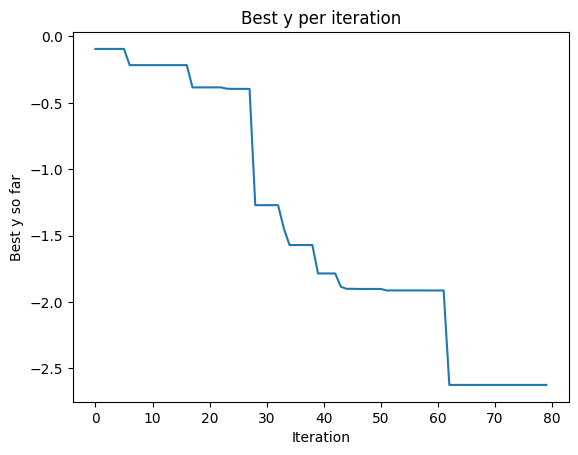

In [ ]:
import matplotlib.pyplot as plt


plt.plot(best_y_per_iteration.values)
plt.xlabel("Iteration")
plt.ylabel("Best y so far")
plt.title("Best y per iteration")

In [ ]:
for iteration in range(30):
    acqf_check = strategy._get_acqfs(n=1)[0]

    # Probe: evaluate acqf at a fixed test point to see if model actually changed
    test_point = torch.zeros(1, 1, bounds.shape[1], **tkwargs)
    test_point[..., 0] = 0.5
    probe_val = acqf_check(test_point).item()

    print(f"\n--- Iteration {iteration} ---")
    print(f"  n_experiments: {len(strategy.experiments)}")
    print(f"  acqf probe at fixed point: {probe_val:.10f}")

    candidate, acq_val = get_candidate()
    print(f"  acq_val from get_candidate: {acq_val}")

    new_experiments = benchmark.f(candidate, return_complete=True)
    print(f"  new y value: {new_experiments['y'].values}")

    n_before = len(strategy.experiments)
    strategy.tell(new_experiments, replace=False)
    n_after = len(strategy.experiments)
    print(f"  experiments: {n_before} -> {n_after}")

    # Check if model params actually changed
    ls = strategy.model.covar_module.lengthscale
    print(f"  lengthscale[0:3]: {ls[0, :3].tolist()}")


--- Iteration 0 ---
  n_experiments: 66
  acqf probe at fixed point: -45.9420604508
  acq_val from get_candidate: -5.48109119224731
  new y value: [-2.97790422]
  experiments: 66 -> 67
  lengthscale[0:3]: [0.2937835994912956, 0.4041666833510878, 4.41966538654436]

--- Iteration 1 ---
  n_experiments: 67
  acqf probe at fixed point: -45.9419739465
  acq_val from get_candidate: -5.645335943157333
  new y value: [-2.99606393]
  experiments: 67 -> 68
  lengthscale[0:3]: [0.30036564796021076, 0.3919503617733176, 4.339199268257635]

--- Iteration 2 ---
  n_experiments: 68
  acqf probe at fixed point: -45.9430990850
  acq_val from get_candidate: -7.4356479767381565
  new y value: [-0.00015728]
  experiments: 68 -> 69
  lengthscale[0:3]: [0.3312261463319473, 0.39313917655484865, 3.5347083776042476]

--- Iteration 3 ---
  n_experiments: 69
  acqf probe at fixed point: -45.9446675469
  acq_val from get_candidate: -6.929772202048997
  new y value: [-0.00067149]
  experiments: 69 -> 70
  lengthsc

/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d

  experiments: 71 -> 72
  lengthscale[0:3]: [0.30018737965437287, 0.4054900134182153, 13.665555661586506]

--- Iteration 6 ---
  n_experiments: 72
  acqf probe at fixed point: -46.0112759163
  acq_val from get_candidate: -6.4480336673718055
  new y value: [-0.00106805]
  experiments: 72 -> 73
  lengthscale[0:3]: [0.2953749217570681, 0.4102799011484572, 13.598938811874865]

--- Iteration 7 ---
  n_experiments: 73
  acqf probe at fixed point: -46.0108940378
  acq_val from get_candidate: -39.15175009566557
  new y value: [-3.00207657]
  experiments: 73 -> 74
  lengthscale[0:3]: [0.2970526387781363, 1.0787512449468613, 3.351634232309813]

--- Iteration 8 ---
  n_experiments: 74
  acqf probe at fixed point: -46.0192865010


/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:795: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:795: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/j30607/sandbox/bofire-worktrees/feature-mcts/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:795: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with st

  acq_val from get_candidate: -12.164814561040743
  new y value: [-0.01646253]
  experiments: 74 -> 75
  lengthscale[0:3]: [0.39385986766547937, 0.3448380489990462, 8.83546958707795]

--- Iteration 9 ---
  n_experiments: 75
  acqf probe at fixed point: -46.0094130418
  acq_val from get_candidate: -5.745335865515177
  new y value: [-0.17019157]
  experiments: 75 -> 76
  lengthscale[0:3]: [0.3044109295808983, 0.3922305605059308, 14.09836815838481]

--- Iteration 10 ---
  n_experiments: 76
  acqf probe at fixed point: -46.0100629356
  acq_val from get_candidate: -45.89948778074979
  new y value: [-0.16469201]
  experiments: 76 -> 77
  lengthscale[0:3]: [0.3055344125405825, 0.40015436028875384, 15.101534607314072]

--- Iteration 11 ---
  n_experiments: 77
  acqf probe at fixed point: -46.0129252589
  acq_val from get_candidate: -45.86736603648621
  new y value: [-0.3761452]
  experiments: 77 -> 78
  lengthscale[0:3]: [0.03089655749767049, 108.44260342490087, 7.957079269897791]

--- Iterati

In [ ]:
best_y_per_iteration = strategy.experiments["y"].cummin()
best_y_per_iteration.values

array([-0.00568271, -0.09673502, -0.09673502, -0.09673502, -0.09673502,
       -0.09713184, -0.61958705, -0.61958705, -0.61958705, -0.61958705,
       -0.61958705, -0.61958705, -0.61958705, -0.61958705, -0.61958705,
       -0.61958705, -0.61958705, -0.61958705, -1.00350188, -1.00350188,
       -1.00350188, -1.00350188, -1.00350188, -1.00350188, -1.00350188,
       -1.11410792, -1.11410792, -1.74733591, -1.74733591, -1.78129139,
       -2.66609372, -2.70018492, -2.70018492, -2.70018492, -2.70018492,
       -2.70018492, -2.70018492, -2.94932638, -2.94932638, -2.94932638,
       -2.94932638, -2.94932638, -2.94932638, -2.94932638, -2.94932638,
       -2.94932638, -2.94932638, -2.94932638, -2.94932638, -2.94932638,
       -2.94932638, -2.94932638, -2.94932638, -2.94932638, -2.94932638,
       -2.95942063, -2.95942063, -2.95942063, -2.95942063, -2.95942063,
       -2.95942063, -2.95942063, -2.96859675, -2.9747409 , -2.9747409 ,
       -2.9747409 , -2.97790422, -2.99606393, -2.99606393, -2.99

Text(0.5, 1.0, 'Best y per iteration')

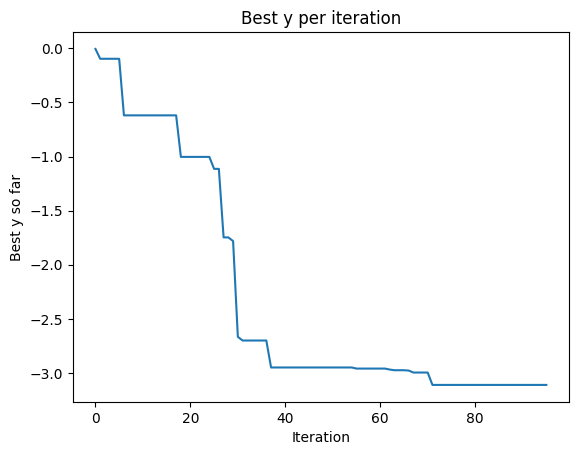

In [ ]:
import matplotlib.pyplot as plt


plt.plot(best_y_per_iteration.values)
plt.xlabel("Iteration")
plt.ylabel("Best y so far")
plt.title("Best y per iteration")

In [ ]:
len(best_y_per_iteration)

96

In [ ]:
len(strategy.experiments)

96

In [ ]:
strategy.experiments.sort_values(by="y")

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
71,0.399952,0.887742,1.0,0.550482,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-3.110493,True
94,0.398006,0.885197,0.0,0.572616,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-3.013107,True
90,0.397789,0.884929,0.0,0.573332,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-3.013040,True
73,0.395858,0.881798,0.0,0.556407,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-3.002077,True
67,0.401852,0.888979,0.0,0.549605,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-2.996064,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,1.000000,0.601740,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.000671,True
44,0.000000,0.000000,0.0,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.000255,True
89,1.000000,1.000000,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.000232,True
68,1.000000,0.482759,0.0,1.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.000157,True


In [ ]:
strategy.experiments.x_0.values

array([0.40246971, 0.49047062, 0.83129865, 0.        , 0.        ,
       0.        , 0.25661052, 0.92627053, 0.        , 0.97370585,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.29692436, 0.30276136,
       0.31188112, 0.        , 0.31113767, 0.31041889, 0.33260343,
       0.33121978, 0.33797472, 0.34426884, 0.        , 0.42236647,
       0.38995489, 0.40404801, 0.40527138, 0.40636354, 0.37343461,
       0.        , 0.46571731, 0.42500977, 0.81058484, 0.44997919,
       0.        , 0.4405271 , 0.43008012, 0.        , 0.        ,
       0.4443915 , 0.        , 0.        , 0.        , 0.43516446,
       0.43388985, 0.44600393, 0.        , 0.        , 0.        ,
       0.42146618, 0.48546936, 0.40232409, 1.        , 0.39738112,
       1.        , 0.41107153, 0.40042298, 0.39872447, 0.        ,
       0.39733587, 0.39918283, 0.40185191, 1.        , 1.        ,
       0.66228013, 0.39995177, 1.        , 0.39585761, 1.     

In [ ]:
strategy.model.covar_module.lengthscale

tensor([[ 0.3920,  0.0251,  5.8860,  1.1981,  7.8354,  0.9001, 15.2773, 13.5841,
         13.1932, 14.4943, 13.7058, 15.2569]], dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.402470,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.637453,0.139919,0.421824,0.671371,0.331502,-0.005683,True
1,0.490471,0.294428,0.000000,0.000000,0.000000,0.925219,0.179482,0.772988,0.480943,0.000000,0.000000,0.000000,-0.096735,True
2,0.831299,0.000000,0.152829,0.233756,0.000000,0.237655,0.217032,0.000000,0.536154,0.000000,0.000000,0.000000,-0.041713,True
3,0.000000,0.829381,0.000000,0.287912,0.000000,0.000000,0.774149,0.000000,0.000000,0.507314,0.731119,0.425413,-0.082572,True
4,0.000000,0.867044,0.134886,0.000000,0.250443,0.251005,0.766267,0.000000,0.021413,0.000000,0.000000,0.000000,-0.045721,True
5,0.000000,0.307729,0.842745,0.116426,0.000000,0.272615,0.000000,0.000000,0.000000,0.778731,0.000000,0.155062,-0.097132,True
6,0.256611,0.494405,0.000000,0.603158,0.000000,0.000000,0.836657,0.000000,0.000000,0.808090,0.000000,0.134337,-0.619587,True
7,0.926271,0.000000,0.000000,0.318856,0.000000,0.000000,0.664589,0.000000,0.492802,0.053163,0.000000,0.259605,-0.003226,True
8,0.000000,0.219118,0.625043,0.788445,0.000000,0.000000,0.000000,0.470343,0.000000,0.000000,0.385520,0.006767,-0.006505,True
9,0.973706,0.000000,0.000000,0.062392,0.000000,0.676559,0.000000,0.805104,0.000000,0.260977,0.402337,0.000000,-0.054280,True


In [ ]:
strategy.model.covar_module.lengthscale

tensor([[0.2561, 0.3035, 1.2614, 1.3028, 1.5076, 1.4546, 1.6381, 1.6320, 1.7198,
         1.9160, 1.4628, 0.4608]], dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.702225,0.119576,0.000000,0.000000,0.514166,0.000000,0.398243,0.000000,0.000000,0.911647,0.000000,0.506541,-0.007801,True
1,0.000000,0.135406,0.843290,0.000000,0.000000,0.000000,0.079528,0.215190,0.761794,0.000000,0.755572,0.000000,-0.008543,True
2,0.000000,0.635161,0.000000,0.757472,0.040300,0.000000,0.058581,0.000000,0.000000,0.000000,0.539834,0.529786,-0.082457,True
3,0.000000,0.000000,0.000000,0.597671,0.156412,0.000000,0.928983,0.936716,0.000000,0.658372,0.000000,0.631700,-0.015096,True
4,0.818524,0.000000,0.000000,0.000000,0.919444,0.682978,0.000000,0.000000,0.696665,0.642777,0.000000,0.947762,-0.000610,True
5,0.000000,0.000000,0.559009,0.459663,0.000000,0.000000,0.064795,0.000000,0.638105,0.947350,0.398382,0.000000,-0.017627,True
6,0.000000,0.006826,0.000000,0.347398,0.609963,0.000000,0.206743,0.945932,0.000000,0.844383,0.000000,0.000000,-0.011483,True
7,0.462412,0.746150,0.043896,0.607946,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.349018,0.801749,-2.436279,True
8,0.000000,0.000000,0.000000,0.744648,0.000000,0.000000,0.204549,0.741898,0.571723,0.431828,0.000000,0.892975,-0.001715,True
9,0.000000,0.757775,0.000000,0.000000,0.000000,0.987737,0.000000,0.000000,0.082688,0.003090,0.465650,0.160617,-0.021754,True


In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_2,x_spurious_3,x_spurious_4,x_spurious_5,y,valid_y
0,0.702225,0.119576,0.000000,0.000000,0.514166,0.000000,0.398243,0.000000,0.000000,0.911647,0.000000,0.506541,-0.007801,True
1,0.000000,0.135406,0.843290,0.000000,0.000000,0.000000,0.079528,0.215190,0.761794,0.000000,0.755572,0.000000,-0.008543,True
2,0.000000,0.635161,0.000000,0.757472,0.040300,0.000000,0.058581,0.000000,0.000000,0.000000,0.539834,0.529786,-0.082457,True
3,0.000000,0.000000,0.000000,0.597671,0.156412,0.000000,0.928983,0.936716,0.000000,0.658372,0.000000,0.631700,-0.015096,True
4,0.818524,0.000000,0.000000,0.000000,0.919444,0.682978,0.000000,0.000000,0.696665,0.642777,0.000000,0.947762,-0.000610,True
5,0.000000,0.000000,0.559009,0.459663,0.000000,0.000000,0.064795,0.000000,0.638105,0.947350,0.398382,0.000000,-0.017627,True
6,0.000000,0.006826,0.000000,0.347398,0.609963,0.000000,0.206743,0.945932,0.000000,0.844383,0.000000,0.000000,-0.011483,True
7,0.462412,0.746150,0.043896,0.607946,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.349018,0.801749,-2.436279,True
8,0.000000,0.000000,0.000000,0.744648,0.000000,0.000000,0.204549,0.741898,0.571723,0.431828,0.000000,0.892975,-0.001715,True
9,0.000000,0.757775,0.000000,0.000000,0.000000,0.987737,0.000000,0.000000,0.082688,0.003090,0.465650,0.160617,-0.021754,True


In [ ]:
mcts = MCTS(
    groups=groups,
    # Dummy reward function — we only use MCTS for tree traversal
    # to sample valid NChooseK combinations.
    reward_fn=reward_fn,
    use_cache=False,
    rollout_mode="uniform_subset",
)
mcts.run(n_iterations=2000)

((5, 35, 42, 47, 48), {}, -4.6231695559517085)

In [ ]:
strategy.experiments

,x_0,x_1,x_2,x_3,x_4,x_5,x_spurious_0,x_spurious_1,x_spurious_10,x_spurious_11,...,x_spurious_41,x_spurious_42,x_spurious_43,x_spurious_5,x_spurious_6,x_spurious_7,x_spurious_8,x_spurious_9,y,valid_y
0,0.000000,0.000000,0.029030,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.117084,0.0,0.000000,-0.005313,True
1,0.308896,0.000000,0.000000,0.551674,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.011710,True
2,0.000000,0.000000,0.861945,0.000000,0.0,0.894800,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.103397,0.0,0.000000,-0.279134,True
3,0.000000,0.787188,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.007694,True
4,0.000000,0.000000,0.833057,0.939468,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.000441,True
5,0.000000,0.464790,0.000000,0.186811,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.833006,0.0,0.00000,0.0,0.0,0.000000,0.0,0.693337,-0.018105,True
6,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.005089,True
7,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.005089,True
8,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.90389,0.0,0.0,0.000000,0.0,0.000000,-0.005089,True
9,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.940792,0.0,0.766596,0.0,...,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.0,0.000000,-0.005089,True


In [ ]:
import math


sum([math.comb(12, i) for i in range(7)])

2510

In [ ]:
strategy

NameError: name 'strategy' is not defined

In [ ]:
strategy.acqf_optimizer._candidates_tensor_to_dataframe(candidates, strategy.domain)

In [ ]:
leaf, path = mcts._select_and_expand()
selected_features, cat_selections = mcts._get_selection(leaf)
print(selected_features)
print(reward_fn(selected_features, cat_selections={}))
print(reward_fn2(selected_features, cat_selections={}))

(5, 37, 48)
-4.677423986870725
-4.664086891505056


In [ ]:
print(
    reward_fn(
        (
            0,
            1,
            2,
            3,
            4,
        ),
        cat_selections={},
    )
)
print(
    reward_fn2(
        (
            0,
            1,
            2,
            3,
            4,
        ),
        cat_selections={},
    )
)

-39.6933963563105
-10.756249958648718


In [ ]:
strategy.model.covar_module.lengthscale

tensor([[ 8.7714,  3.3755,  0.2549,  0.0688,  2.2844,  1.9798, 13.7240,  6.4729,
          3.0276,  0.1636, 12.4373, 12.4482]], dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
experiments.y.min()

np.float64(-0.2791335862611258)

In [ ]:
selected_features, _, _ = mcts._rollout(mcts.root)
print(selected_features)
print(reward_fn(selected_features, cat_selections={}))

(18,)
-32.97498755616551


In [ ]:
experiments.y.min()

np.float64(-0.4820260292929051)

In [ ]:
reward_fn(
    [
        31,
        49,
    ],
    cat_selections={},
)

-8.419034388799723

In [ ]:
experiments[["x_3"]].sum()

x_3    0.0
dtype: float64

In [ ]:
benchmark.domain.inputs.get_keys()[3]

'x_3'

In [ ]:
bounds.shape

torch.Size([2, 50])